# End-to-End Pipeline & Full Analysis Suite

This notebook runs the **entire scHopfield method from a single call** with `sch.run_pipeline`, then walks through every analysis you can derive from the fitted model: the energy landscape, Jacobian stability, network drivers, eigenanalysis, and in-silico perturbation.

We use the mouse hematopoiesis dataset (Paul et al., 2015) with a CellOracle base GRN as a prior-knowledge scaffold, and validate the perturbation predictions against known erythroid/myeloid master regulators.


## 8.1 Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scHopfield as sch

sch.set_seed(0)

CLUSTER_KEY = 'paul15_clusters'   # 19 hematopoietic states
BASIS       = 'draw_graph_fa'     # force-directed embedding shipped with the data
DEVICE      = 'cuda'              # or 'cpu'

# Literature-established master regulators used later for KO validation
ERY = ['1Ery', '2Ery', '3Ery', '4Ery', '5Ery', '6Ery', '7MEP']
MYE = ['9GMP', '10GMP', '11DC', '12Baso', '13Baso', '14Mo', '15Mo', '16Neu', '17Neu', '18Eos']
PANEL = {'Gata1': -1, 'Klf1': -1, 'Spi1': +1, 'Cebpa': +1}  # +1 KO->myeloid-block, -1 KO->erythroid-block


## 8.2 Load data

The dataset is already velocity-preprocessed (it carries `Ms`, `velocity_S`, `sigmoid`, `gamma`, and a neighbour graph). For a raw dataset you would first call `sch.pp.prepare_dataset`, or pass `prepare=True` to `run_pipeline`.


In [2]:
adata = sc.read_h5ad('data/hematopoiesis/base_preprocessed.h5ad')
base_GRN = pd.read_parquet('data/hematopoiesis/base_GRN.parquet')
print(f'{adata.n_obs} cells x {adata.n_vars} genes, {adata.obs[CLUSTER_KEY].nunique()} clusters')


2671 cells x 1999 genes, 19 clusters


## 8.3 The whole pipeline in one call

We keep the most dynamic genes (plus the KO panel), build a scaffold from the base GRN, and hand everything to `run_pipeline`, which fits the cell-type GRNs, computes the energy landscape, the per-cell Jacobian eigenvalues, and the network centrality, all written back into `adata`.


In [3]:
# 1. keep top-velocity genes (force-keeping the KO panel), then build the scaffold
adata = sch.workflows.select_top_velocity_genes(adata, 300, keep_genes=list(PANEL))
adata.var['scHopfield_used'] = True
scaffold, n_tf, n_edge = sch.inf.build_scaffold(adata, base_GRN, return_stats=True)
print(f'scaffold: {n_tf} TFs, {n_edge} edges over {adata.n_vars} genes')

# 2. one call: GRN fit (scaffold-guided) -> energies -> Jacobians -> centrality
adata = sch.run_pipeline(
    adata,
    cluster_key=CLUSTER_KEY,
    scaffold=scaffold.values.T,          # fit_interactions expects W[target, regulator]
    fit_kwargs=dict(scaffold_regularization=0.1, reconstruction_regularization=100,
                    bias_regularization=1, n_epochs=400, batch_size=128,
                    refit_gamma=True, include_neighbors=True, neighbor_fraction=0.2),
    device=DEVICE, seed=0, copy=False,
)


scaffold: 13 TFs, 1977 edges over 304 genes
Inferring interaction matrix W and bias vector I for cluster 7MEP
  Including 402 neighboring cells (167 cluster + 402 neighbors = 569 total)


[Epoch 1/400] Total Loss: 46.469188, Reconstruction Loss: 17.971327, LR: 1.00e-01, Batch size: 128


[Epoch 101/400] Total Loss: 2.619086, Reconstruction Loss: 0.102285, LR: 1.00e-01, Batch size: 128


[Epoch 201/400] Total Loss: 2.697625, Reconstruction Loss: 0.111738, LR: 1.00e-01, Batch size: 128


[Epoch 301/400] Total Loss: 2.708533, Reconstruction Loss: 0.114211, LR: 1.00e-01, Batch size: 128


...

Computing Jacobians for cluster 11DC


Computing Jacobians for cluster 19Lymph


[scHopfield] compute_jacobians + stats


[scHopfield] compute_network_centrality


[scHopfield] pipeline complete: 2671 cells x 304 genes, 19 clusters


In [4]:
# what the single call produced:
print('pipeline steps :', adata.uns['scHopfield_pipeline']['steps'])
print('per-cell energy:', [k for k in adata.obs if k.startswith('energy_')])
print('per-cell stab. :', [k for k in adata.obs if k.startswith('jacobian_')])
print('per-cluster GRN:', [k for k in adata.varp if k.startswith('W_')][:3], '...')


pipeline steps : ['fit_interactions (scaffold)', 'compute_energies', 'compute_jacobians + stats', 'compute_network_centrality']
per-cell energy: ['energy_total', 'energy_interaction', 'energy_degradation', 'energy_bias']
per-cell stab. : ['jacobian_eig1_real', 'jacobian_eig1_imag', 'jacobian_positive_evals', 'jacobian_negative_evals', 'jacobian_trace']
per-cluster GRN: ['W_7MEP', 'W_15Mo', 'W_3Ery'] ...


## 8.4 Energy landscape

scHopfield assigns every cell a Lyapunov energy, decomposed into interaction, degradation, and bias terms. Terminal states sit in deeper wells (lower energy) than the multipotent progenitors.


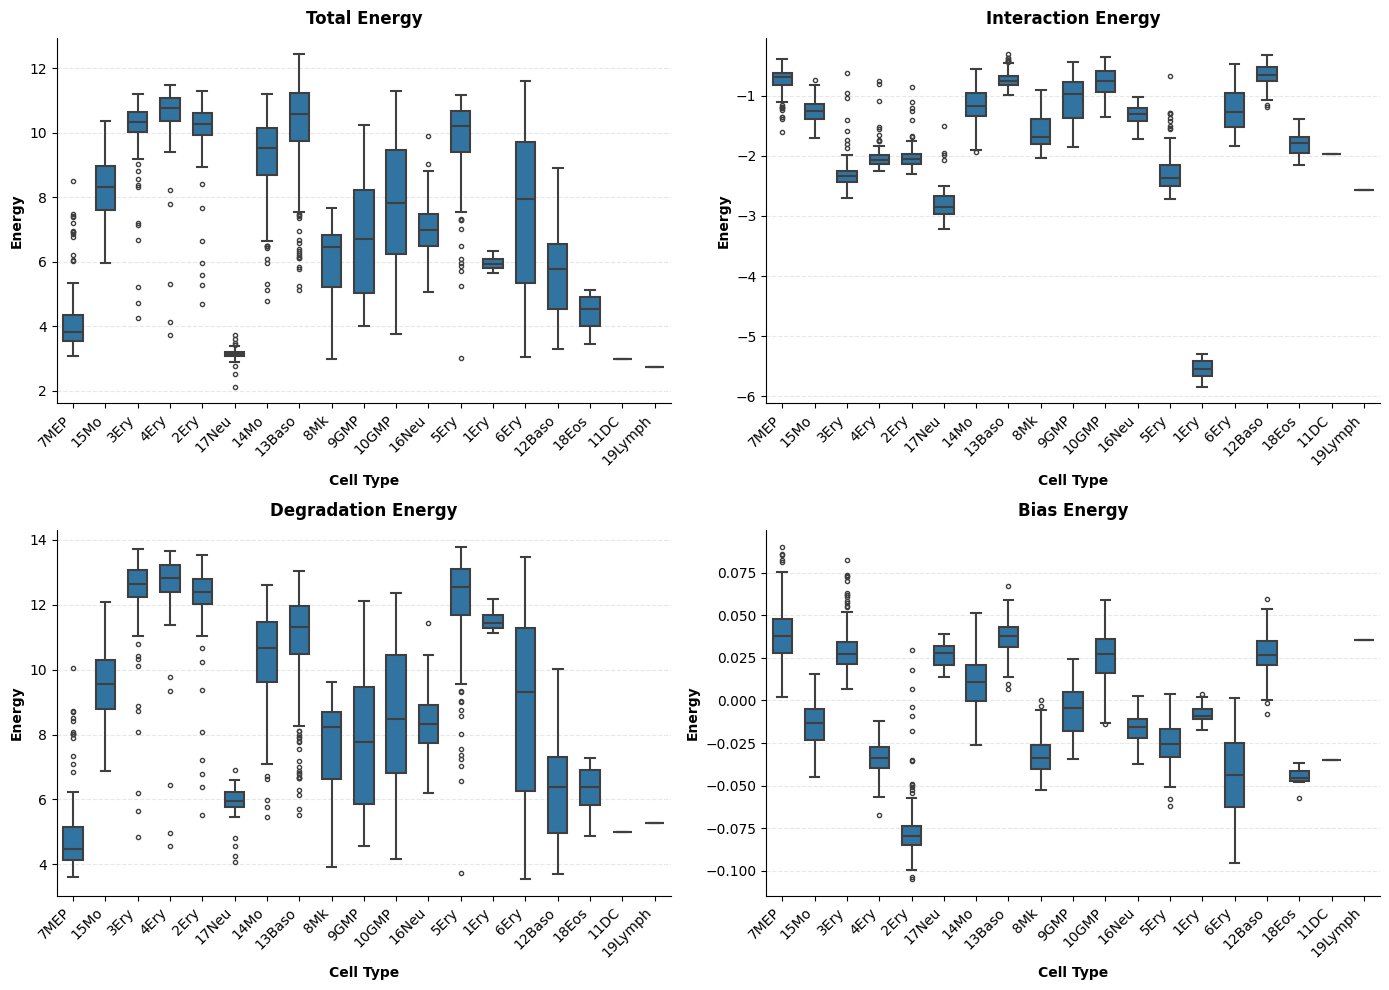

In [5]:
sch.pl.plot_energy_boxplots(adata, cluster_key=CLUSTER_KEY, plot_energy='all')
plt.show()


## 8.5 Jacobian stability

The Jacobian of the dynamics at each cell state gives a local stability readout. A positive leading eigenvalue marks an unstable (progenitor-like) state; a negative one marks a stable attractor.


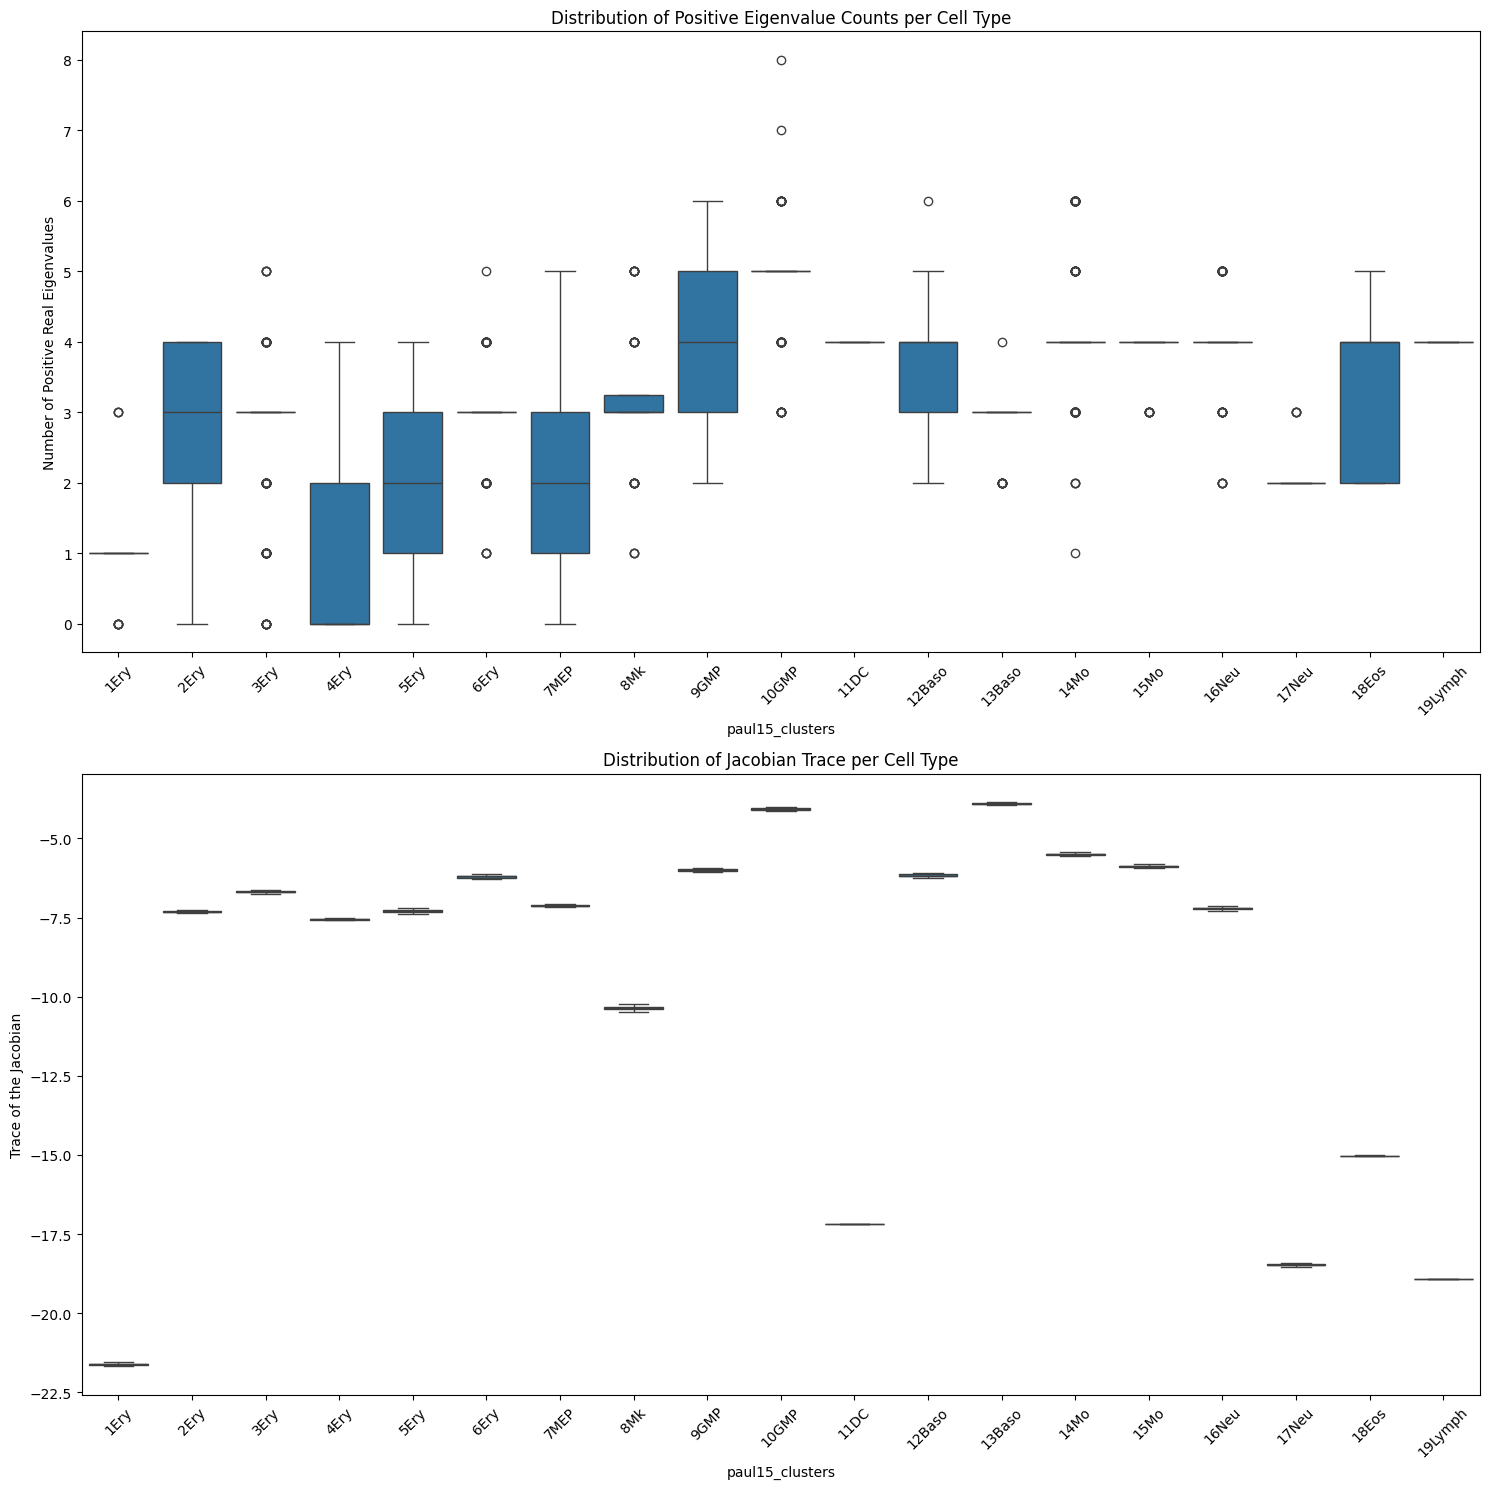

In [6]:
sch.pl.plot_jacobian_stats_boxplots(adata, cluster_key=CLUSTER_KEY)
plt.show()


## 8.6 Network drivers

The fitted GRNs are ordinary matrices, so we can rank driver genes by network centrality and inspect the regulatory graph of any cell type.


In [7]:
top = sch.tl.get_top_genes_table(adata, metric='degree_centrality_all',
                                 cluster_key=CLUSTER_KEY, n_genes=10)
top.head(10)


7MEP                           15Mo                         3Ery  \
      Gene Degree Centrality All     Gene Degree Centrality All   Gene   
0     Klf1              0.656766     Klf1              0.689769  Cebpa   
1     Spi1              0.653465     Spi1              0.686469   Spi1   
2     Cbx5              0.597360    Cebpa              0.597360   Klf1   
3     Nfe2              0.554455     Lmo2              0.590759   Ybx1   
4     Ybx1              0.547855  Smarcc2              0.561056  Gata1   
5     Lmo2              0.541254    Gata1              0.541254   Cbx5   
6    Cebpa              0.534653     Cbx5              0.511551   Lmo2   
7     Cux1              0.508251     Nfe2              0.498350   Cux1   
8      Myb              0.504950      Myb              0.498350    Myb   
9  Smarcc1              0.504950     Cux1              0.485149   Nfe2   

                            4Ery                         2Ery  \
  Degree Centrality All     Gene Degree Centrality All   Gene   
0              0.815182     Klf1              0.722772  Cebpa   
1              0.775578     Spi1              0.706271   Klf1   
2              0.732673    Cebpa              0.676568  Gata1   
3              0.567657     Ybx1              0.587459   Spi1   
4              0.564356    Gata1              0.557756   Cux1   
5              0.551155     Cbx5              0.554455   Ybx1   
6              0.495050     Cux1              0.511551   Cbx5   
7              0.445545     Lmo2              0.485149    Myb   
8              0.425743      Myb              0.481848    Myc   
9              0.399340  Smarcc1              0.465347   Lmo2   

                         ...     6Ery                         12Baso  \
  Degree Centrality All  ...     Gene Degree Centrality All     Gene   
0              0.712871  ...     Klf1              0.732673     Spi1   
1              0.686469  ...     Cbx5              0.623762     Cbx5   
2              0.633663  ...    Cebpa              0.620462     Ybx1   
3              0.617162  ...     Spi1              0.617162    Cebpa   
4              0.524752  ...     Ybx1              0.597360     Lmo2   
5              0.511551  ...     Lmo2              0.541254    Gata1   
6              0.498350  ...    Gata1              0.537954      Myc   
7              0.475248  ...     Cux1              0.501650  Smarcc2   
8              0.462046  ...  Smarcc2              0.465347     Nfe2   
9              0.458746  ...  Smarcc1              0.438944     Klf1   

                           18Eos                           11DC  \
  Degree Centrality All     Gene Degree Centrality All     Gene   
0              0.630363    Gata1              0.689769     Spi1   
1              0.590759     Klf1              0.607261    Gata1   
2              0.584158      Myc              0.590759     Klf1   
3              0.580858     Spi1              0.577558     Ybx1   
4              0.574257     Ybx1              0.561056     Nfe2   
5              0.557756  Smarcc1              0.537954    Cebpa   
6              0.528053      Myb              0.511551      Myc   
7              0.521452     Lmo2              0.504950  Smarcc1   
8              0.475248     Cbx5              0.481848     Cux1   
9              0.475248     Nfe2              0.468647     Cbx5   

                         19Lymph                        
  Degree Centrality All     Gene Degree Centrality All  
0              0.716172     Nfe2              0.785479  
1              0.683168     Klf1              0.722772  
2              0.679868     Spi1              0.600660  
3              0.584158    Gata1              0.577558  
4              0.570957      Myc              0.567657  
5              0.528053     Ybx1              0.521452  
6              0.511551  Smarcc2              0.518152  
7              0.481848     Lmo2              0.495050  
8              0.438944    Cebpa              0.468647  
9              0.435644  Smarcc1       

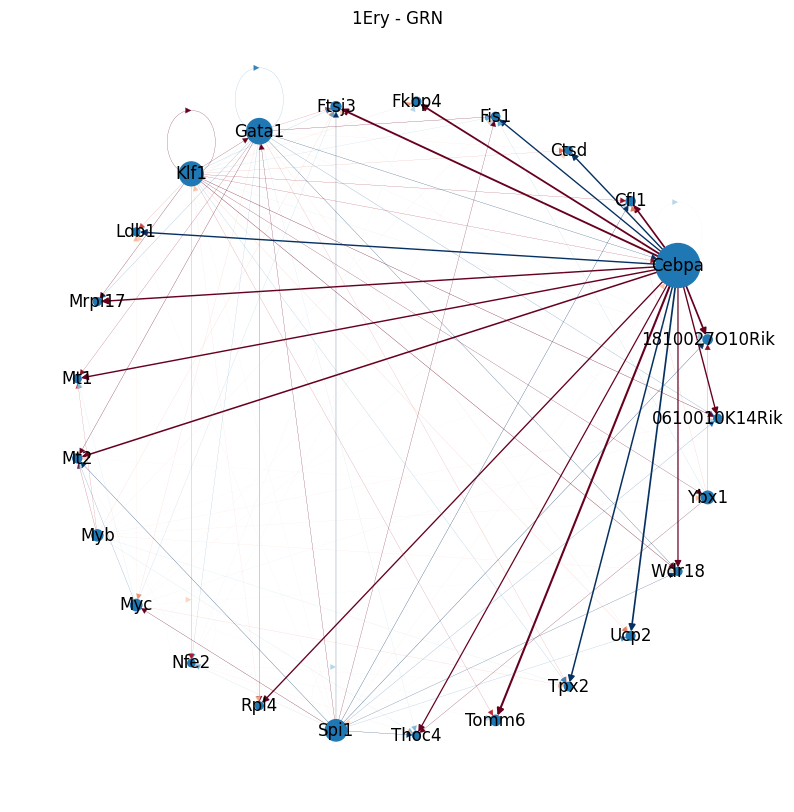

In [8]:
sch.pl.plot_grn_network(adata, cluster='1Ery', cluster_key=CLUSTER_KEY, topn=25)
plt.show()


## 8.7 Eigenanalysis

Eigen-decomposition of each interaction matrix surfaces the dominant regulatory modes per cell type.


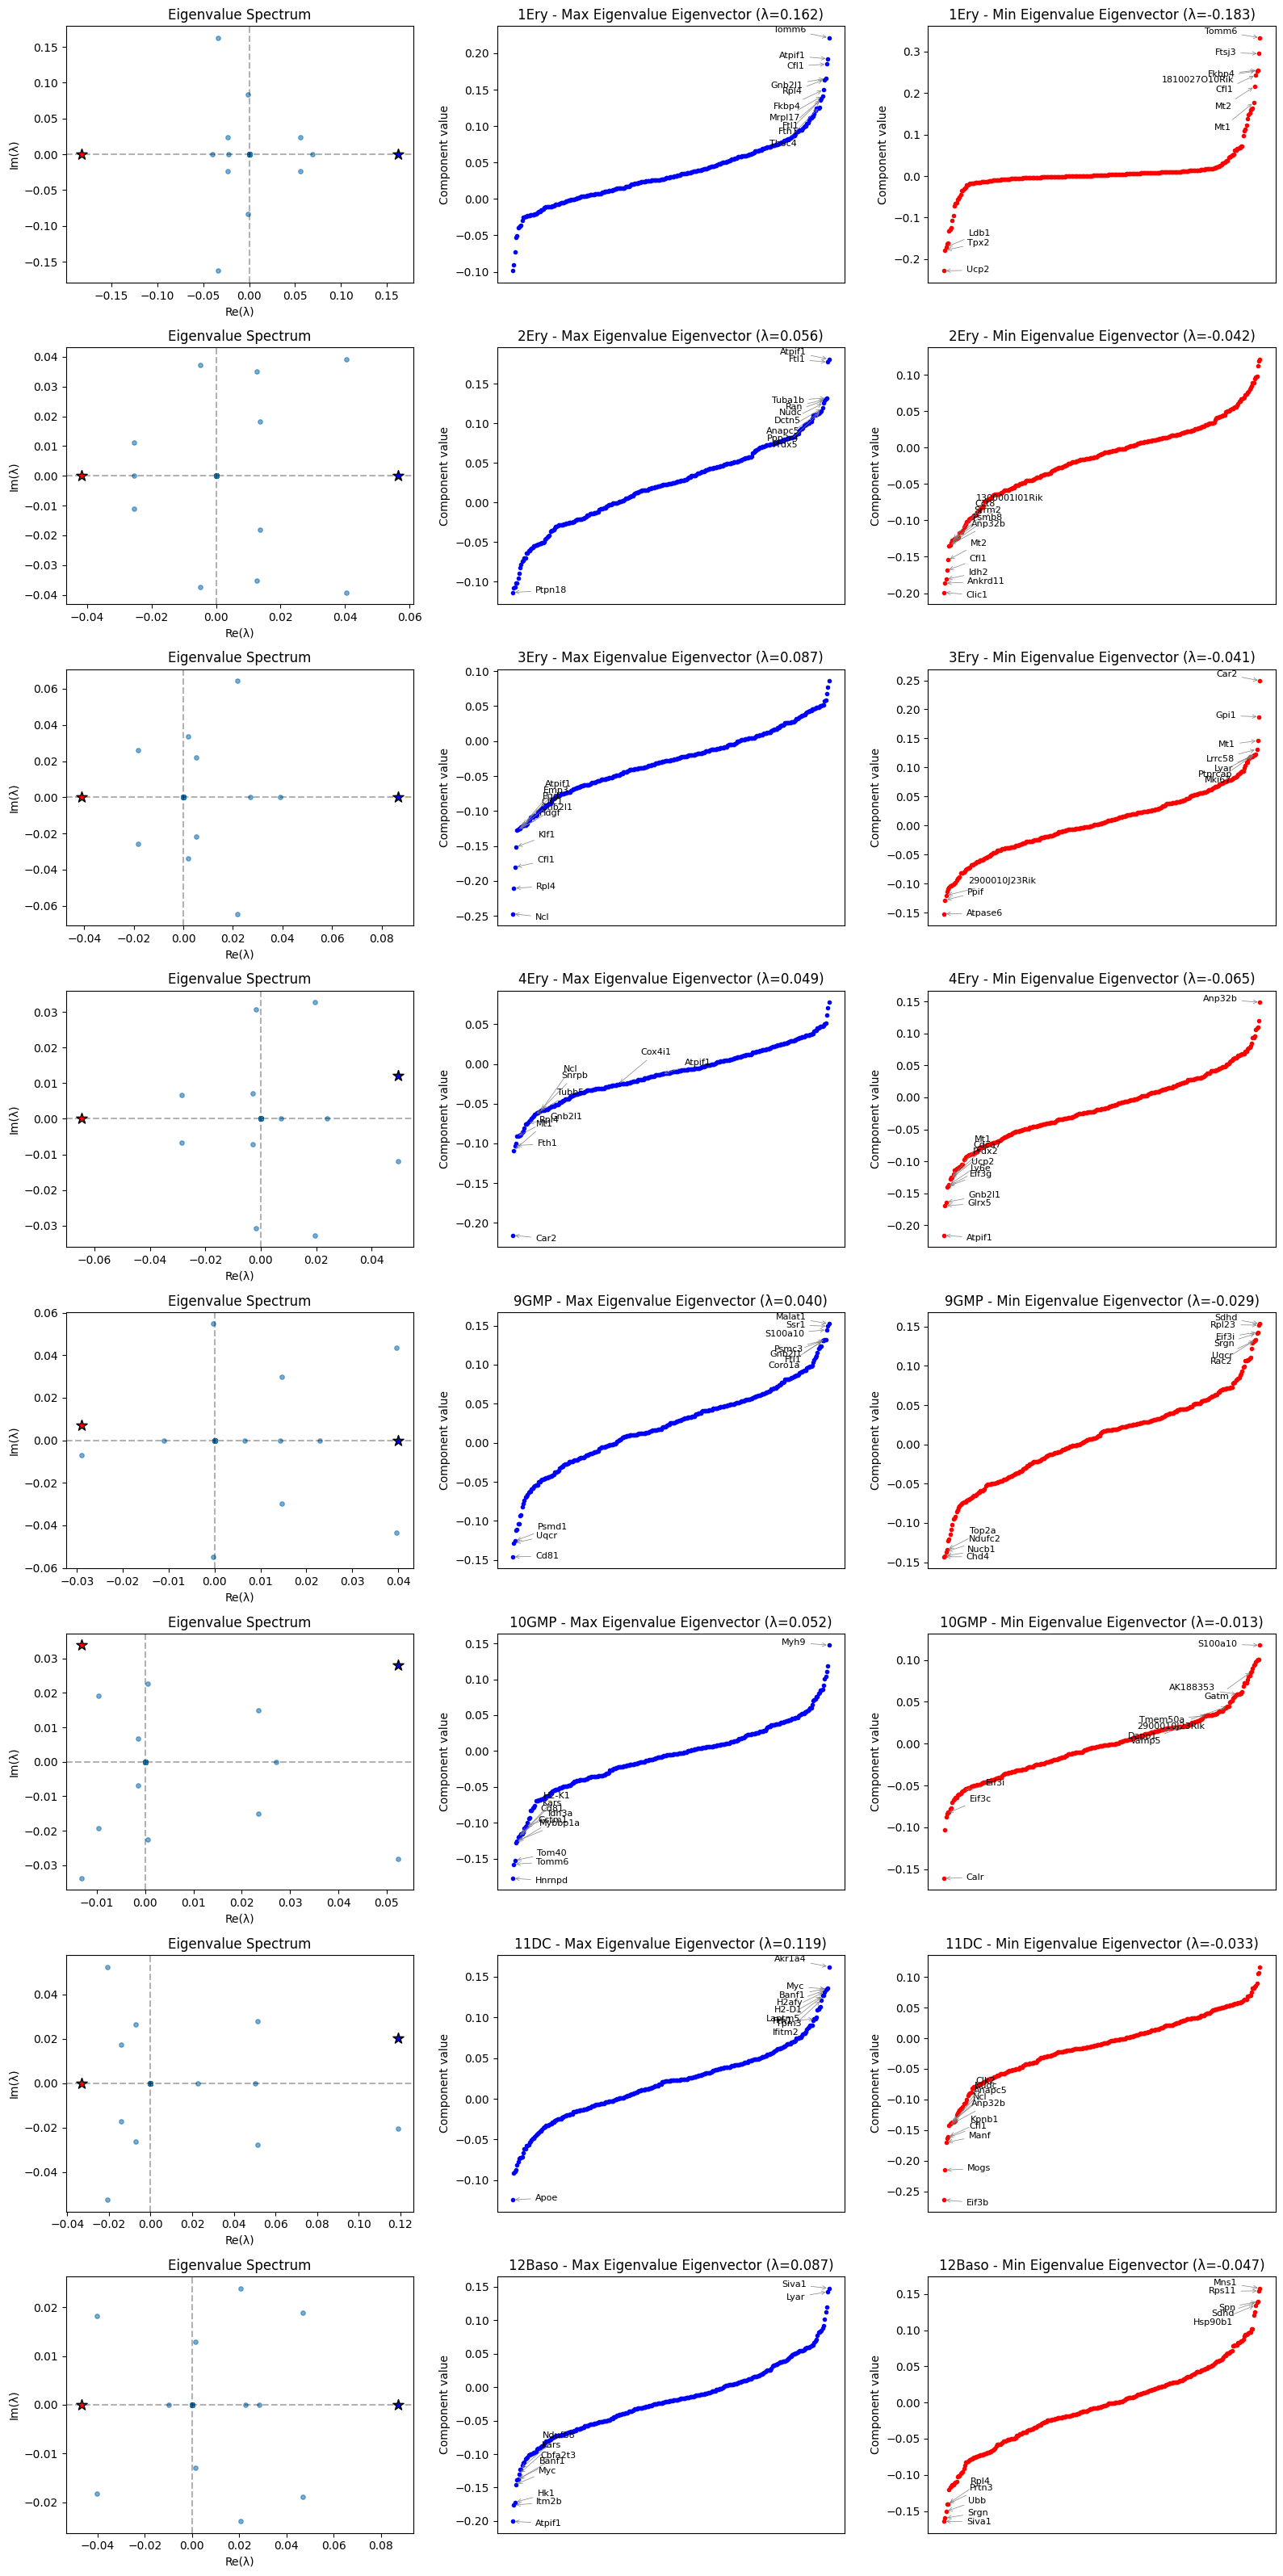

In [9]:
sch.tl.compute_eigenanalysis(adata, cluster_key=CLUSTER_KEY)
sch.pl.plot_eigenanalysis_grid(adata, cluster_key=CLUSTER_KEY, order=ERY[:4] + MYE[:4])
plt.show()


## 8.8 In-silico perturbation

Knock out a gene and propagate the effect through the learned GRN (CellOracle style). Here we knock out **Gata1**, the erythroid master regulator.


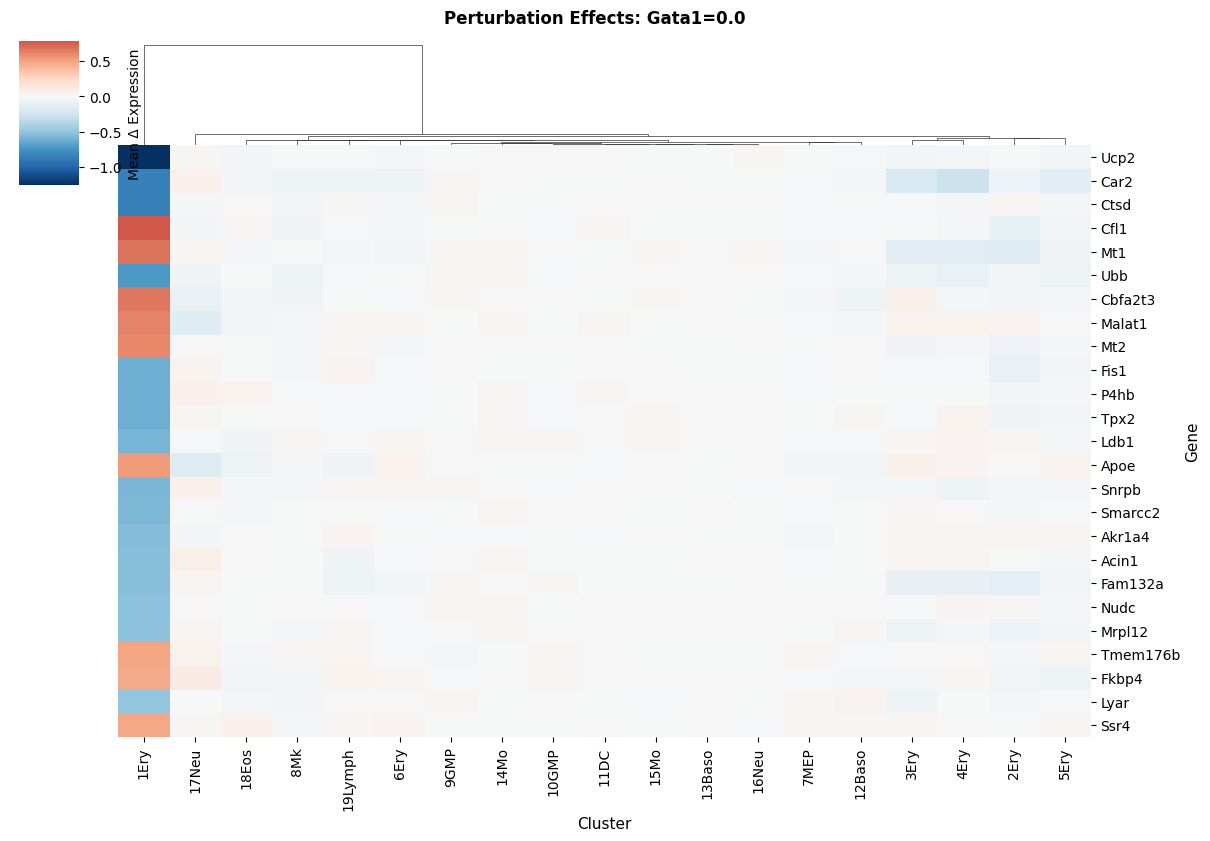

In [10]:
ko = sch.dyn.simulate_perturbation(adata, perturb_condition={'Gata1': 0.0},
                                   cluster_key=CLUSTER_KEY, n_propagation=3, verbose=False)
sch.pl.plot_perturbation_effect_heatmap(ko, cluster_key=CLUSTER_KEY, n_genes=25)
plt.show()


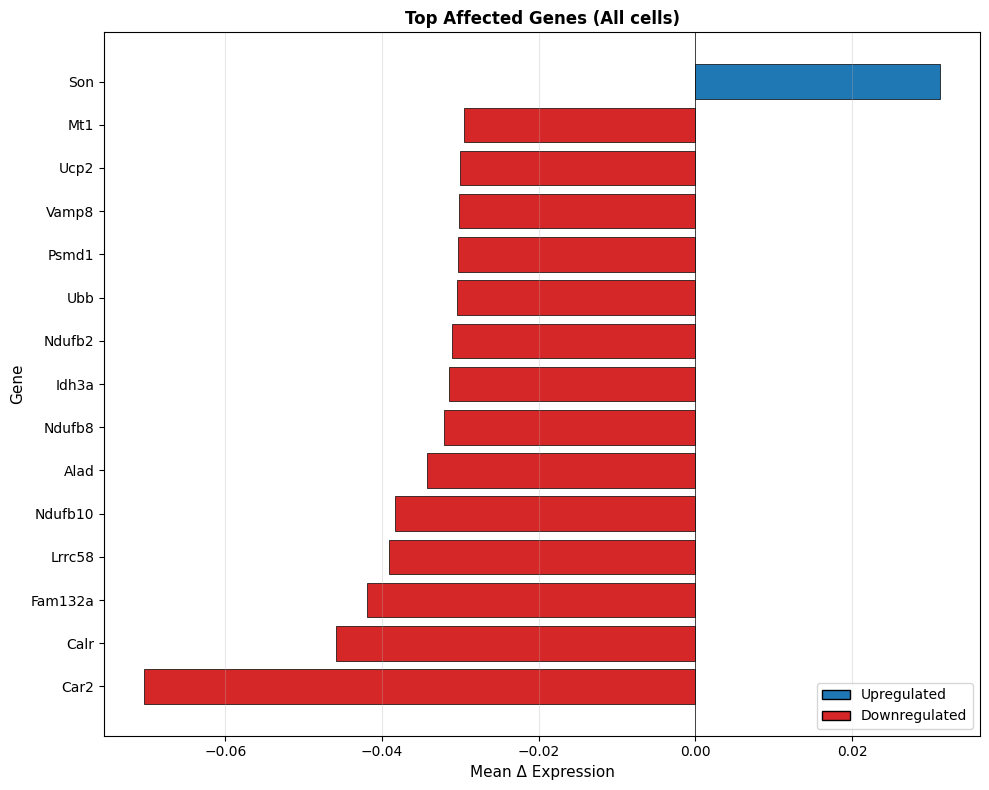

In [11]:
sch.pl.plot_top_affected_genes_bar(ko, n_genes=15)
plt.show()


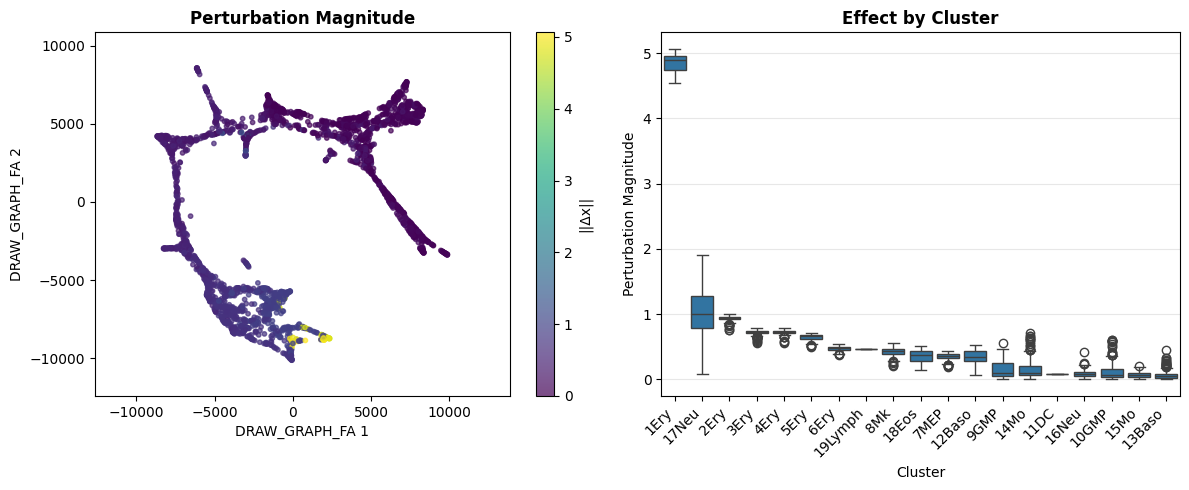

In [12]:
# per-cluster magnitude of the predicted Gata1-KO shift on the embedding
sch.pl.plot_perturbation_magnitude(ko, cluster_key=CLUSTER_KEY, basis=BASIS)
plt.show()


## 8.9 Known-driver KO validation

A ground-truth-anchored check: knocking out an erythroid master should bias cells toward myeloid fate and vice versa. `score_ko_panel` runs the KO screen and scores the **direction** of each predicted lineage shift against expectation.


In [13]:
# wild-type Hopfield velocity flow in the embedding (reference for lineage bias)
sch.tl.calculate_flow(adata, source='original', basis=BASIS, method='hopfield',
                      cluster_key=CLUSTER_KEY, store_key='wt_flow', verbose=False)

table, accuracy = sch.dyn.score_ko_panel(
    adata, panel=PANEL, lineage_A_clusters=ERY, lineage_B_clusters=MYE,
    basis=BASIS, wt_flow_key='wt_flow', cluster_key=CLUSTER_KEY, verbose=False)
print(f'directional accuracy: {accuracy:.0%}')
table


directional accuracy: 100%


,gene,lineage_bias,expected_sign,pred_sign,correct
0,Gata1,-0.1876,-1,-1,True
1,Klf1,-0.2657,-1,-1,True
2,Spi1,0.2461,1,1,True
3,Cebpa,0.0617,1,1,True


## 8.10 Perturbation flow on the embedding

Projecting the KO shift into the embedding shows how the predicted flow field redirects away from the erythroid branch after Gata1 loss.


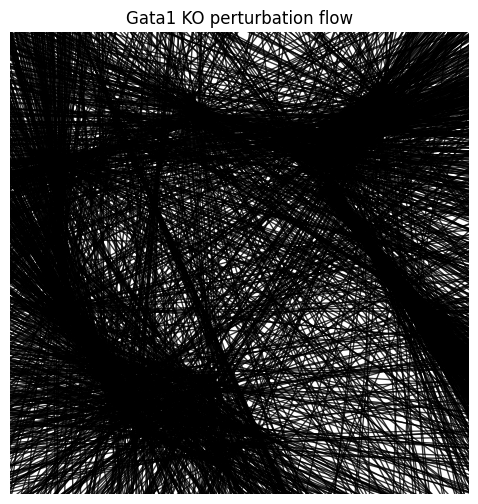

In [14]:
sch.tl.calculate_flow(ko, source='delta', basis=BASIS, method='hopfield',
                      cluster_key=CLUSTER_KEY, store_key='gata1_ko_flow', verbose=False)
fig, ax = plt.subplots(figsize=(7, 6))
sch.pl.plot_flow(ko, flow_key='gata1_ko_flow', basis=BASIS, ax=ax)
ax.set_title('Gata1 KO perturbation flow'); plt.show()


## Summary

From a **single `run_pipeline` call** we obtained cell-type GRNs, a Lyapunov energy landscape, per-cell Jacobian stability, network drivers, eigenmodes, and in-silico perturbation, and validated the knockouts against known hematopoietic master regulators. Each step is also available as a standalone function, see the API reference and the other tutorials.
